# Matthew Pollard and Patrick Dela Rosa

# Milestone 2

Our contributions for each part of the assignment are denoted by our initials.

In [21]:
from herbie import Herbie
import pandas as pd, numpy as np, xarray as xr
import matplotlib.pyplot as plt

# Designing the Threat Index (Winter Weather Impacts on Energy Demand) (MP and PD)
- We will look at and design an index based on two main impacts on energy demand caused by winter weather, which are power outages and overall increased demand for heating due to colder weather
- Increased ice and snow accumulation can cause excess weight on power lines, trees, and branches which can cause these tress to fall onto power lines or these power lines to fall themselves
- Wind gusts can also increase the chance of branches and power lines collapsing
- With power being out, demand for electricity is still needed and not available, further increasing energy demand for crude oil and natural gas.
- On the other hand, extreme cold will highly increase the demand of in home heating needed, increasing the demand for energy
- This can lead to potential shortages and high costs of crude oil and natural gas.
## Target Audience
- Our target audience can be the general public so that they can see when energy prices will increase and decrease before receiving their electricity bills.
- Another audience can be utility and energy companies to account for extra demand during these times of winter weather.  They can inform their clients when demand may increase, causing clients' energy utility prices to increase, as well.
## Scale/Range
- We will make the range from 0-10 with 0 being no impacts on the demand of energy based on winter weather impacts and 10 being extreme impacts
- This is an easy to read scale while also being somewhat precise with allowing for decimal place accuracy
## Variables Used
- The variables we will be using are precipitation type, precipitation rate, 10m wind gust, wind chill, and 2m temperature
## Weighting of variables
- P-type: 27.5%
- P-rate: 10%
- 10m wind gust: 20%
- Wind Chill: 27.5%
- 2m Temperature: 15%
- We chose to weight p-type and 10m wind gust high due to potential effects of power outages being higher based on snow/wet snow/ice and strong wind gusts being impactful for power outages
- Wind chill is also weighted highly because this is the temperature that people are feeling outside, causing them to increase heating in their homes if this is low
- 2m temperature and p-rate are weighted slightly lower because 2m temperature is not exactly what the public is feeling, but still impactful for precipitaton type. Precipitation rate is impactful to see how much precipitation can fall in a ceratain amount of time, but not as impactful as the type of precipitation. For example, if there is a strong rate of rain, it will not have much impact on power lines.
### Lowest possible values
- No precipitation, 2m temp > 40F, wind chill > 40F, 10m wind gust < 10kt, p-rate < 0.1 in/hr, p-type - rain or none
### Highest possible values
- Snow, wet snow, and ice will be the "worst" precipitation types, p-rate > 1 in/hr, wind chill < 0 F, 2m temp < 10F, 10m wind gust > 35 kt

# Calculation of Variables (MP)
- AI assisted development of functions after we defined each threat index calculation

In [22]:
import cartopy.crs as ccrs, cartopy.feature as cfeature
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, BoundaryNorm

In [23]:
ds_test = xr.open_dataset("ecmwf_update5.nc").load()
ds_test

sh: 1: getfattr: not found


<xarray.Dataset> Size: 182MB
Dimensions:            (valid_time: 17, latitude: 161, longitude: 281,
                        isobaricInhPa: 13)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 136B 2026-01-23 ... 2026-0...
  * latitude           (latitude) float64 1kB 60.0 59.75 59.5 ... 20.25 20.0
  * longitude          (longitude) float64 2kB -130.0 -129.8 ... -60.25 -60.0
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-01-23
    step               (valid_time) timedelta64[ns] 136B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Data variables:
    t2m                (valid_time, latitude, longitude) float32 3MB 256.7 .....
    fg10               (valid_time, latitude, longitude) float32 3MB 0.0 ... nan
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 40MB ...
    tp                 (valid_time, latitude, longitude) float32 3MB 0.0 ... ...
    sd                 (valid_time, latitude, longitude) float32 3MB 0.1411 ....
    ptype              (valid_time, latitude, longitude) float32 3MB 0.0 ... 1.0
    tprate             (valid_time, latitude, longitude) float32 3MB 0.0 ... ...
    sp                 (valid_time, latitude, longitude) float32 3MB 8.972e+0...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-27T14:58 GRIB to CDM+CF via cfgrib-0.9.1...

### Time Functions

In [24]:
def get_time_info(ds, time_index, make_strings=True):
    valid_time = ds.valid_time[time_index]
    init_time = ds.valid_time.values[0]
    return valid_time, init_time

In [25]:
def get_time_slice(ds, time_index):
    ds_t = ds.isel(valid_time=time_index)
    init_time = pd.to_datetime(ds.valid_time.values[0])
    valid_time = pd.to_datetime(ds.valid_time.values[time_index])
    init_str = init_time.strftime("%HZ %d %b %Y")
    valid_str = valid_time.strftime("%HZ %d %b %Y")
    return ds_t, init_str, valid_str

In [88]:
time_index = 11
ds_t, init_str, valid_str = get_time_slice(ds_test, time_index)

# Wind Chill Index (MP)

In [26]:
def compute_wind_chill(ds, time_index):
    wind_gust = ds['fg10'].isel(valid_time=time_index).values
    t2m = ds['t2m'].isel(valid_time=time_index).values
    # convert temperature to F
    t2m_F = (t2m - 273.15) * 9/5 + 32
    # convert wind speed to mph
    V_mph = wind_gust * 2.237
    # wind chill formula
    wind_chill = (35.74 + 0.6215 * t2m_F - 35.75 * (V_mph ** 0.16) + 0.4275 * t2m_F * (V_mph ** 0.16))
    # apply validity mask
    wind_chill = np.where((t2m_F <= 50) & (V_mph >= 3), wind_chill, t2m_F)
    return wind_chill

## Meaning of function (MP)¶
- Between -20 and -10, values decrease linearly from 1 to 0.9
- Between -10 and zero, values decrease linearly from 0.9 to 0.8
- Between 0 and 20, values decrerase linearly from 0.8 to 0.5
- Between 20 and 40, values decrease linearly from 0.5 to 0
- Was overwriting ranges originally using the example code from MS2, so I used ChatGPT to define a single function to sort through these values

In [27]:
def wind_chill_contribution(wind_chill):
    WC_contribution = np.clip(
        1.0
        - 0.1 * np.clip((wind_chill + 20) / 10, 0, 1)   # -20 → -10
        - 0.1 * np.clip((wind_chill + 10) / 10, 0, 1)   # -10 → 0
        - 0.3 * np.clip((wind_chill - 0) / 20, 0, 1)    # 0 → 20
        - 0.5 * np.clip((wind_chill - 20) / 20, 0, 1),  # 20 → 40
        0, 1
    )
    return WC_contribution * 10

In [91]:
time_index = 14

wind_chill = compute_wind_chill(ds_test, time_index)

wc_index = wind_chill_contribution(wind_chill)

In [323]:
wc_index

array([[ 8.694575 ,  8.7482815,  8.377746 , ..., 10.       , 10.       ,
         9.454067 ],
       [ 9.363717 ,  8.856366 ,  8.669875 , ..., 10.       , 10.       ,
         9.815479 ],
       [ 9.081086 ,  9.059481 ,  9.19362  , ..., 10.       , 10.       ,
        10.       ],
       ...,
       [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ],
       [ 0.       ,  0.       ,  0.       , ...,  0.       ,  0.       ,
         0.       ]], shape=(161, 281), dtype=float32)

# Precpitation rate index function (MP)

In [28]:
tprate = ds_test['tprate'].values

In [29]:
tprate_in = tprate*141.73
tprate_in.max()

np.float32(1.3705994)

## Index weighting precip rate (testing)
- Greatest value in data set is 0.88 in/hr, defined above that prate>1 will be the "worst condition". Although it is not present in this dataset, I think we will still use this as the worst condition
- 0-0.1 in/hr lowest contribution 0
- 0.1-0.3 in/hr moderate contribution (0 to 0.2)
- 0.3-0.5 in/hr higher contribution (0.4 to 0.6)
- 0.5-0.8 in/hr very large threat (0.6 to 0.8)
- 0.8-1 in/hr highest threat (0.8 to 1)

In [30]:
def precip_rate_contribution(tprate_in):
    contribution = np.clip(
        0.0
        + 0.2 * np.clip((tprate_in - 0.1) / 0.2, 0, 1)
        + 0.4 * np.clip((tprate_in - 0.3) / 0.3, 0, 1)
        + 0.2 * np.clip((tprate_in - 0.5) / 0.2, 0, 1)
        + 0.2 * np.clip((tprate_in - 0.8) / 0.2, 0, 1),
        0, 1
    )
    return contribution * 10

In [31]:
time_index = 11

tprate = ds_test['tprate'].isel(valid_time=time_index).values
tprate_in = tprate*141.73
tprate_in = np.clip(tprate_in, 0, 1)

tprate_index = precip_rate_contribution(tprate_in)

# Precipitaton type index (MP)

In [14]:
     # 0 = No precipitation
     # 1 = Rain
     # 3 = Freezing rain
     # 5 = Snow
     # 6 = Wet snow
     # 7 = Rain/Snow mix
     # 8 = Ice pellets
     # 12 = Freezing drizzle

## Index values
- Freezing rain has the largest impact
- Wet snow second largest 
- Freezing drizzle, although lighter precipitation it can accumulate better than heavy freezing rain
- Snow fourth largest, but it is much more common and will be weighted similarly to wet snow (5)
- Ice pellets have fifth largest impact
- Rain/snow mix has sixth largest
- Rain has little impact
- No precip has no impact

In [32]:
def precip_type_contribution(ptype):
    ptype_scale = {
        0: 0,  # None
        1: 1,  # Rain
        7: 2,  # Rain/snow mix
        8: 3,  # Ice pellets
        5: 4,  # Snow
        12: 5, # Freezing drizzle
        6: 6,  # Wet snow
        3: 7   # Freezing rain
    }
    # Convert ptype to ranked severity
    ptype_rank = np.vectorize(ptype_scale.get)(ptype)
    contribution = np.clip(
        0.0
        + 0.25 * np.clip((ptype_rank - 1) / 2, 0, 1)   # Rain → Mix
        + 0.25 * np.clip((ptype_rank - 3) / 2, 0, 1)   # Ice → Snow
        + 0.25 * np.clip((ptype_rank - 5) / 1, 0, 1)   # FZDZ → Wet snow
        + 0.25 * np.clip((ptype_rank - 6) / 1, 0, 1),  # Wet snow → FZRA
        0, 1
    )
    return contribution * 10

In [33]:
time_index = 11
ptype = ds_test['ptype'].isel(valid_time=time_index).values
ptype_index = precip_type_contribution(ptype)

# Wind Gust Index (PD)

In [34]:
# wind gust
wgust = ds_test['fg10'] * 1.94384449

# initialize
wind_hazard = xr.zeros_like(wgust)

# middle range: 10–35 kt
mask_mid = (wgust >= 10) & (wgust <= 35)
wind_hazard = wind_hazard.where(
    ~mask_mid,
    10 * ((wgust - 10) / 25.0) ** 2
)

# above 35 kt → cap at 10
wind_hazard = wind_hazard.where(wgust <= 35, 10)

In [35]:
def wind_gust_contribution(ds, time_index):
    # convert m/s to knots
    wgust = ds['fg10'].isel(valid_time=time_index) * 1.94384449
    # initialize
    wind_hazard = xr.zeros_like(wgust)
    # middle range: 10–35 kt
    mask_mid = (wgust >= 10) & (wgust <= 35)
    wind_hazard = wind_hazard.where(
        ~mask_mid,
        10 * ((wgust - 10) / 25.0) ** 2
    )
    # above 35 kt → cap at 10
    wind_hazard = wind_hazard.where(wgust <= 35, 10)
    return wind_hazard

In [36]:
time_index = 11
gust_index = wind_gust_contribution(ds_test, time_index)

## Index Explanation
- A quadratic equation is used for the wind gust index contribution because low wind gusts will not cause significant damage to the power grid, but high wind gusts above 30 kt may compromise power lines much more effectively. 
- In our case, wind gusts below 10 kt may not noticeably cause damage to power lines (index of 0), but gusts above 35 kt may cause a lot of damage (index of 10).
- One of the criteria for a blizzard is sustained wind speeds of at least 35 mph for 3 hours, and we are using knots, which is higher than mph, so a wind gust index contribution of 10 implies that this blizzard criterion is fully satisfied (assuming that it lasts at a location for at least 3 hours), which fits the theme with our winter weather hazards index for energy demand due to power loss.

# 2m Temp Index (PD)

In [37]:
# 2m temp
t2m = ds_test['t2m'].values
t2m_F = (t2m - 273.15) * 9/5 + 32
temp_index = 10 * ((40 - t2m_F) / 30)

# Apply bounds
temp_index = temp_index.clip(min=0, max=10)

In [38]:
def temp_contribution(t2m_F):
    temp_index = 10 * ((40 - t2m_F) / 30)
    # Apply bounds
    temp_index = np.clip(temp_index, 0, 10)
    return temp_index

In [39]:
time_index = 11
t2m = ds_test['t2m'].isel(valid_time=time_index).values
# convert K → F
#t2m_F = (t2m - 273.15) * 9/5 + 32
temp_index = temp_contribution(t2m_F)

## Index Explanation
- A linear equation is used for the temperature index contribution because household heating demand tends to increase linearly with decreasing temperature.
- This is referring to Heating Degree Days (HDD), which are defined as HDD = 65F-{mean outside temp in degrees F}.  The lower the outside temperature, the more heating energy demand required to adequately heat up a house.
- Temperatures above 40 F tend to be near or above average in the Northern U.S. during the heart of winter and tend to feel relatively managebale to most people in the winter, especially if wind speeds are low.  Also, temperatures above 40 F usually do not lead to much lower wind chills, even with high wind speeds, which lead to a minimum index contribution of 0.
- Temperatures below 10 F feel very frigid to most people and will put significant strain on household energy needs and crude oil and natural gas inventories, which will highly increase energy prices and lead to a maximum index of 10.

# Defining function for overall threat index (MP)

In [40]:
def compute_threat_index(ptype_idx, prate_idx, gust_idx, wc_idx, temp_idx):
    threat_index = (
        0.275 * ptype_idx +
        0.1 * prate_idx +
        0.2 * gust_idx +
        0.275 * wc_idx +
        0.15  * temp_idx
    )
    return threat_index

In [41]:
def compute_threat_index_full(ds, time_index):
    # wind chill
    wind_chill = compute_wind_chill(ds, time_index)
    wc_index = wind_chill_contribution(wind_chill)

    # precip rate
    tprate = ds['tprate'].isel(valid_time=time_index).values * 141.732
    prate_index = precip_rate_contribution(tprate)

    # precip type
    ptype = ds['ptype'].isel(valid_time=time_index).values
    ptype_index = precip_type_contribution(ptype)

    # wind gust
    gust_index = wind_gust_contribution(ds, time_index)

    # temperature
    t2m = ds['t2m'].isel(valid_time=time_index).values
    t2m_F = (t2m - 273.15) * 9/5 + 32
    temp_index = temp_contribution(t2m_F)

    # final index
    return compute_threat_index(
        ptype_index,
        prate_index,
        gust_index,
        wc_index,
        temp_index
    )

In [21]:
ds_test.valid_time

<xarray.DataArray 'valid_time' (valid_time: 17)> Size: 136B
array(['2026-01-23T00:00:00.000000000', '2026-01-23T06:00:00.000000000',
       '2026-01-23T12:00:00.000000000', '2026-01-23T18:00:00.000000000',
       '2026-01-24T00:00:00.000000000', '2026-01-24T06:00:00.000000000',
       '2026-01-24T12:00:00.000000000', '2026-01-24T18:00:00.000000000',
       '2026-01-25T00:00:00.000000000', '2026-01-25T06:00:00.000000000',
       '2026-01-25T12:00:00.000000000', '2026-01-25T18:00:00.000000000',
       '2026-01-26T00:00:00.000000000', '2026-01-26T06:00:00.000000000',
       '2026-01-26T12:00:00.000000000', '2026-01-26T18:00:00.000000000',
       '2026-01-27T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 136B 2026-01-23 ... 2026-0...
    time               datetime64[ns] 8B 2026-01-23
    step               (valid_time) timedelta64[ns] 136B 0 days 00:00:00 ... ...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Attributes:
    standard_name:  time
    long_name:      time

## Testing different visualizations and times (Timestep 2) (MP)

In [42]:
time_index = 8
ds_t, init_str, valid_str = get_time_slice(ds_test, time_index)

In [47]:
threat_index_test = compute_threat_index_full(ds_test, 11)

In [44]:
def GeoAxes():
    fig = plt.figure(figsize=(15,9))
    ax = plt.axes(projection=ccrs.LambertConformal())
    ax.set_extent([-120,-70,25,50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
    ax.add_feature(cfeature.STATES.with_scale('50m'), linestyle=':')
    ax.add_feature(cfeature.BORDERS.with_scale('50m'))
    return fig, ax  

In [45]:
# prelims
lat = ds_test.latitude.values
lon = ds_test.longitude.values
dataproj = ccrs.PlateCarree()

Text(0.5, 1.0, 'ECMWF Winter Weather Impacts on Energy Demand Index\nInit: 00Z 23 Jan 2026  Valid: 18Z 25 Jan 2026')

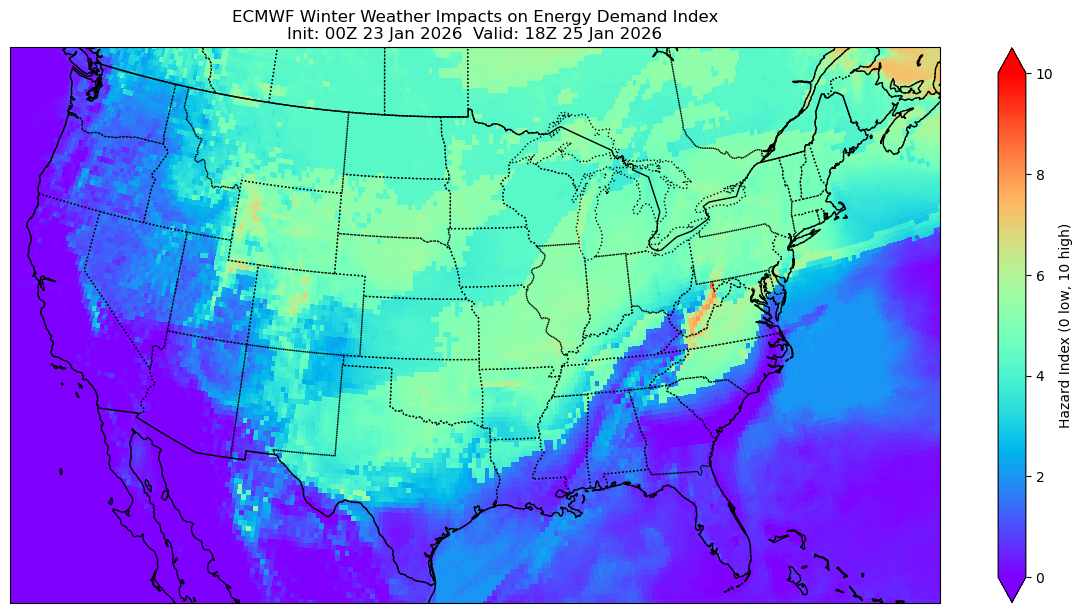

In [48]:
fig, ax = GeoAxes()

ds_t, init_str, valid_str = get_time_slice(ds_test, 11)
mesh = ax.pcolormesh(lon, lat, threat_index_test, vmin=0, vmax=10, cmap = 'rainbow',  transform=ccrs.PlateCarree())
plt.colorbar(mesh, label = 'Hazard Index (0 low, 10 high)', extend = 'both', shrink=0.8)
ax.set_title(f"ECMWF Winter Weather Impacts on Energy Demand Index\nInit: {init_str}  Valid: {valid_str}")

# Visualizing the Output (MP and PD)
- We are choosing timesteps of 1, 3, 5, 8, 11, 14 in our data with 11 being the data used in Milestone 1.
- We defined overall funcitons to easily reproduce small amounts of code for each timestep
- Used AI assistance for developing the plot panel as well as understanding how to create the plot_winter_threats and how it works

In [49]:
def GeoAxes2d():
    fig, axs = plt.subplots(2,3, figsize = (28,10), subplot_kw={"projection":ccrs.LambertConformal()})
    for ax in axs.flatten():
        ax.set_extent([-120,-70,25,50], ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
        ax.add_feature(cfeature.STATES.with_scale('50m'), linestyle=':')
        ax.add_feature(cfeature.BORDERS.with_scale('50m'))
    return fig, axs

In [50]:
# time function
def get_time_strings(ds, time_index):
    init_time = pd.to_datetime(ds.valid_time.values[0])
    valid_time = pd.to_datetime(ds.valid_time.values[time_index])
    return (
        init_time.strftime("%HZ %d %b %Y"),
        valid_time.strftime("%HZ %d %b %Y")
    )

In [51]:
def plot_panel(ax, lon, lat, data, title, cmap, vmin=None, vmax=None,
               norm=None, label="", transform=ccrs.PlateCarree()):
    mesh = ax.pcolormesh(
        lon, lat, data,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        norm=norm,
        transform=transform
    )
    cbar = plt.colorbar(mesh, ax=ax, shrink=0.85, extend="both")
    cbar.set_label(label)
    ax.set_title(title)
    return mesh

In [52]:
# Defining custom colormaps above function

# Precipitation Rate Colormap
prate_bounds = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 1.0, 2.0]
prate_colors = ["white","blue","lightgreen","green","yellow","orange","red"]
prate_cmap = ListedColormap(prate_colors)
prate_norm = BoundaryNorm(prate_bounds, prate_cmap.N)

# Precipitation Type Colormap
ptype_colors = [
    "white",      # 0 = None
    "green",      # 1 = Rain
    "red",        # 3 = Freezing rain
    "blue",       # 5 = Snow
    "cyan",       # 6 = Wet snow
    "purple",     # 7 = Mix
    "orange",     # 8 = Ice pellets
    "pink"        # 12 = Freezing drizzle
]
ptype_values = [0,1,3,5,6,7,8,12]
ptype_cmap = ListedColormap(ptype_colors)
ptype_norm = BoundaryNorm(ptype_values + [13], ptype_cmap.N)

In [53]:
# overall plot function
def plot_winter_threat(ds, time_index, lon, lat):

    init_str, valid_str = get_time_strings(ds, time_index)

    # compute variables
    wind_chill = compute_wind_chill(ds, time_index)
    wc_index = wind_chill_contribution(wind_chill)

    t2m = ds['t2m'].isel(valid_time=time_index).values
    t2m_F = (t2m - 273.15) * 9/5 + 32
    temp_index = temp_contribution(t2m_F)

    wgust = ds['fg10'].isel(valid_time=time_index).values * 1.94384449
    gust_index = wind_gust_contribution(ds, time_index)

    tprate = ds['tprate'].isel(valid_time=time_index).values * 141.732
    prate_index = precip_rate_contribution(tprate)

    ptype = ds['ptype'].isel(valid_time=time_index).values
    ptype_index = precip_type_contribution(ptype)

    hazard_index = compute_threat_index(
        ptype_index,
        prate_index,
        gust_index,
        wc_index,
        temp_index
    )

    fig, axs = GeoAxes2d()

    plot_panel(axs[0,0], lon, lat, hazard_index,
               f"ECMWF Winter Weather Impacts on Energy Demand Index\nInit: {init_str}  Valid: {valid_str}",
               cmap="rainbow", vmin=0, vmax=10,
               label="Hazard Index")

    plot_panel(axs[0,1], lon, lat, t2m_F,
               f"ECMWF 2m Temperature (°F)\nInit: {init_str}  Valid: {valid_str}",
               cmap="coolwarm", vmin=-20, vmax=80,
               label="Temp (°F)")

    plot_panel(axs[0,2], lon, lat, wgust,
               f"ECMWF 10m Wind Gust (kt)\nInit: {init_str}  Valid: {valid_str}",
               cmap="coolwarm", vmax=45,
               label="Wind Gust")

    plot_panel(axs[1,0], lon, lat, tprate,
               f"ECMWF Precip Rate (in/hr)\nInit: {init_str}  Valid: {valid_str}",
               cmap=prate_cmap, norm=prate_norm,
               label="Precip Rate")

    plot_panel(axs[1,1], lon, lat, wind_chill,
               f"ECMWF Wind Chill (°F)\nInit: {init_str}  Valid: {valid_str}",
               cmap="coolwarm", vmin=-20, vmax=80,
               label="Wind Chill")

    # precip type
    mesh = axs[1,2].pcolormesh(lon, lat, ptype,
                               cmap=ptype_cmap,
                               norm=ptype_norm,
                               transform=ccrs.PlateCarree())

    cbar = plt.colorbar(mesh, ax=axs[1,2], shrink=0.75)
    cbar.set_ticks(ptype_values)
    cbar.set_ticklabels([
        "None","Rain","Frz Rain","Snow",
        "Wet Snow","Mix","Ice Pellets","Frz Drizzle"
    ])

    axs[1,2].set_title(f"ECMWF Precipitation Type\nInit: {init_str}  Valid: {valid_str}")

    fig.subplots_adjust(wspace=0.25, hspace=0.25)

    return fig

## Timestep 1 (2026-01-23 06UTC) (MP)

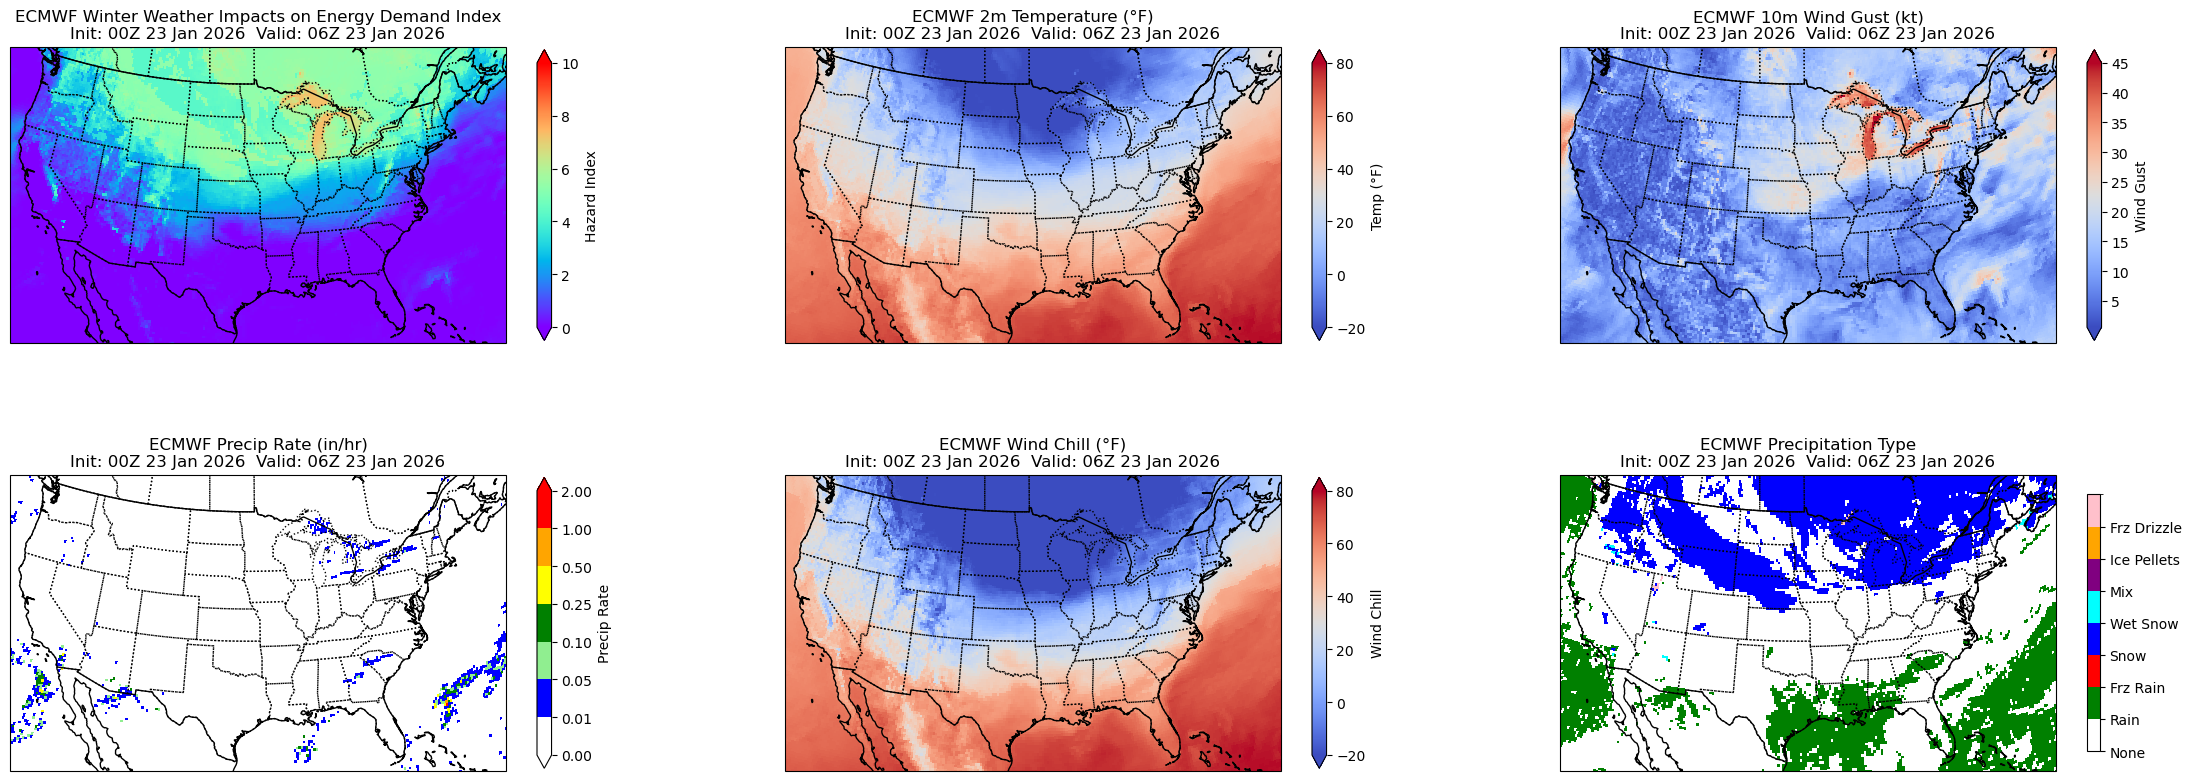

In [54]:
time_steps = [1, 3, 5, 8, 11, 14]

fig = plot_winter_threat(ds_test, 1, lon, lat)
plt.show()

## Timestep 3 (2026-01-23 18UTC) (MP)

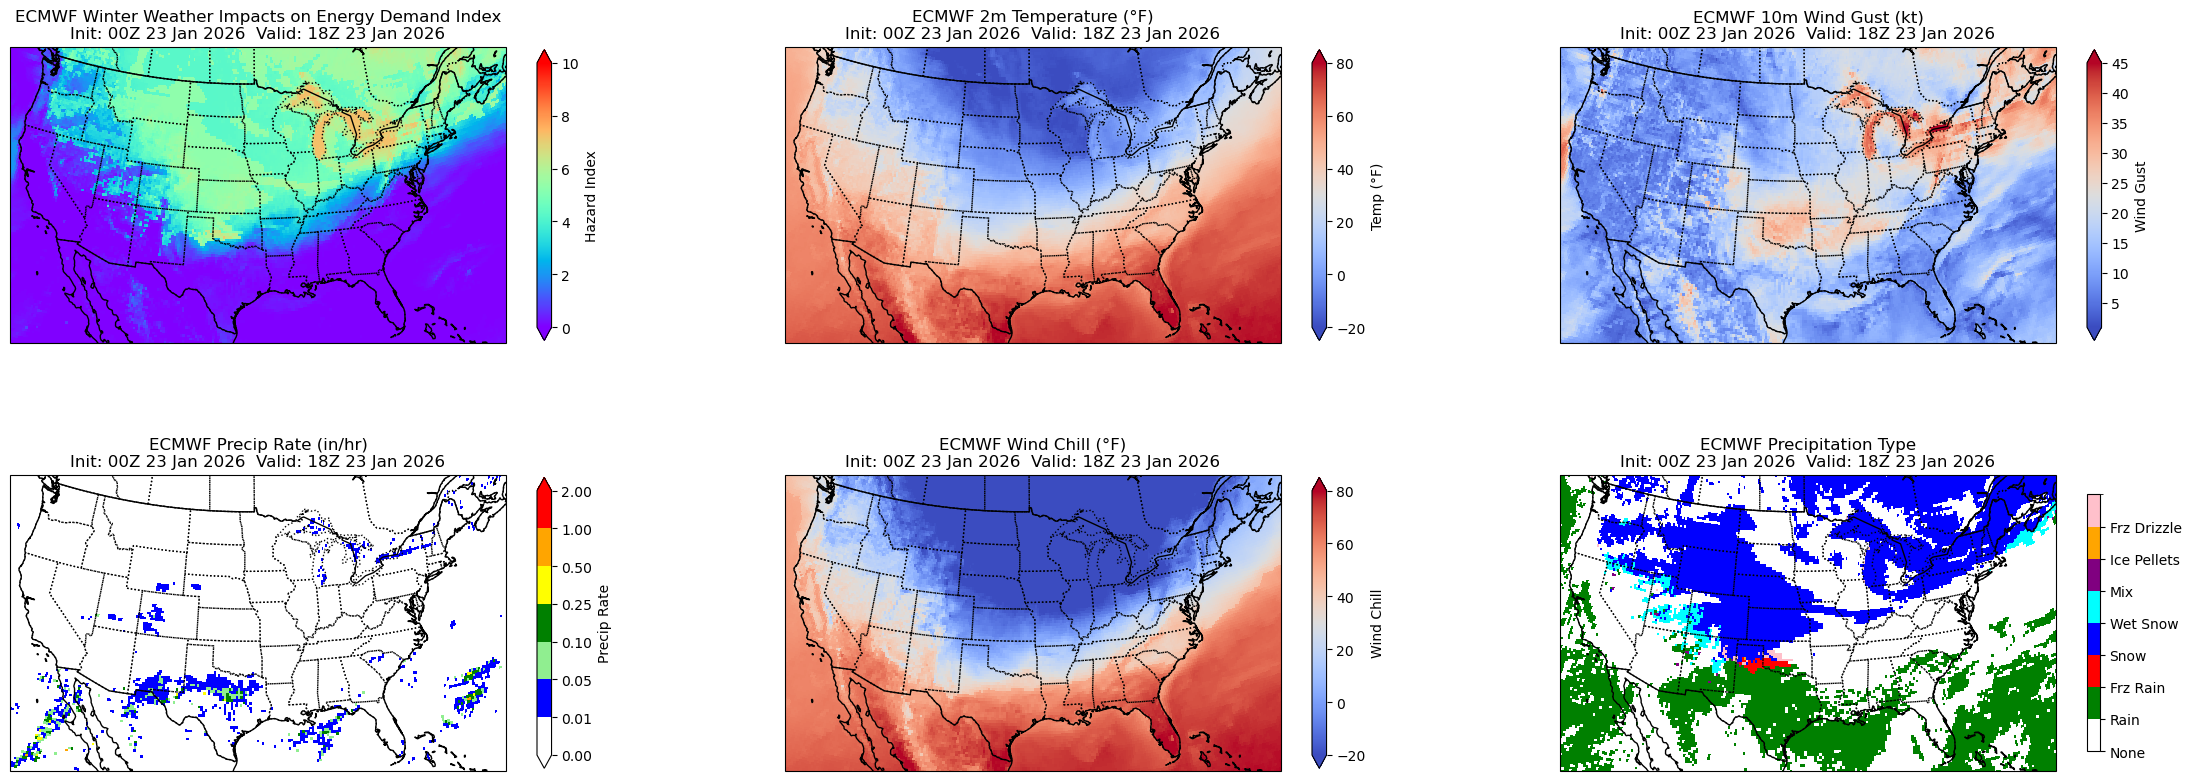

In [128]:
time_steps = [1, 3, 5, 8, 11, 14]

fig = plot_winter_threat(ds_test, 3, lon, lat)
plt.show()

## Timestep 5 (2026-01-24 06 UTC) (MP)

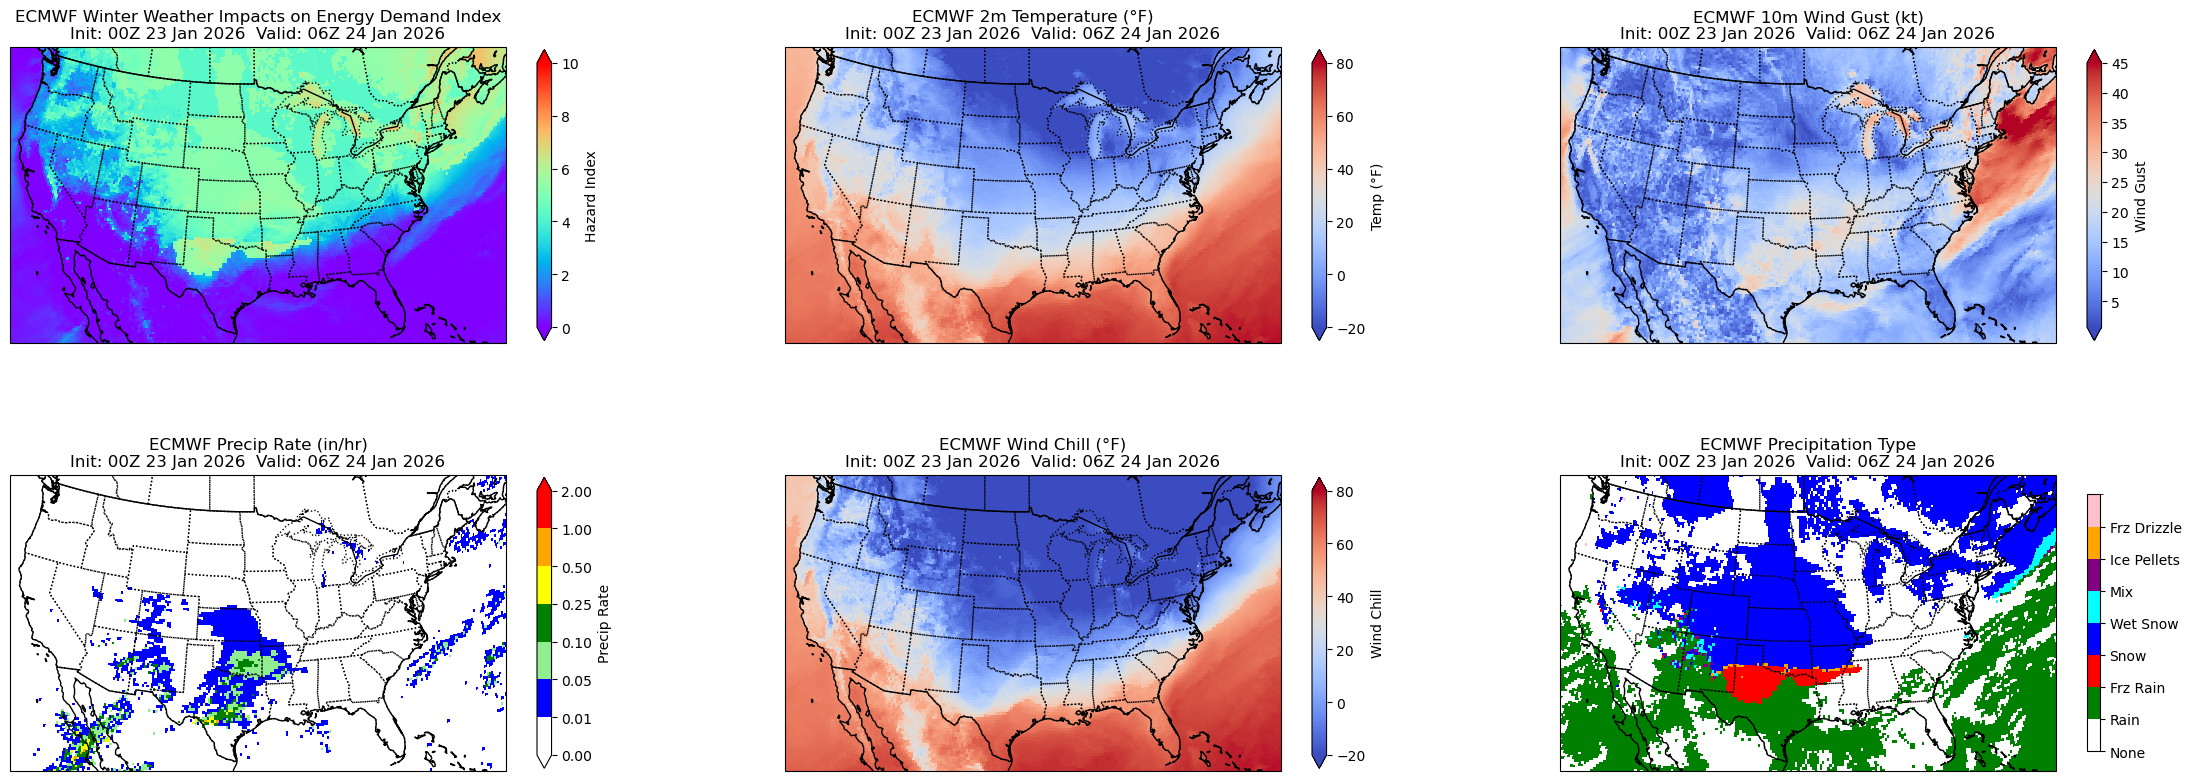

In [129]:
time_steps = [1, 3, 5, 8, 11, 14]

fig = plot_winter_threat(ds_test, 5, lon, lat)
plt.show()

## Timestep 8 (2026-01-25 00 UTC) (PD)

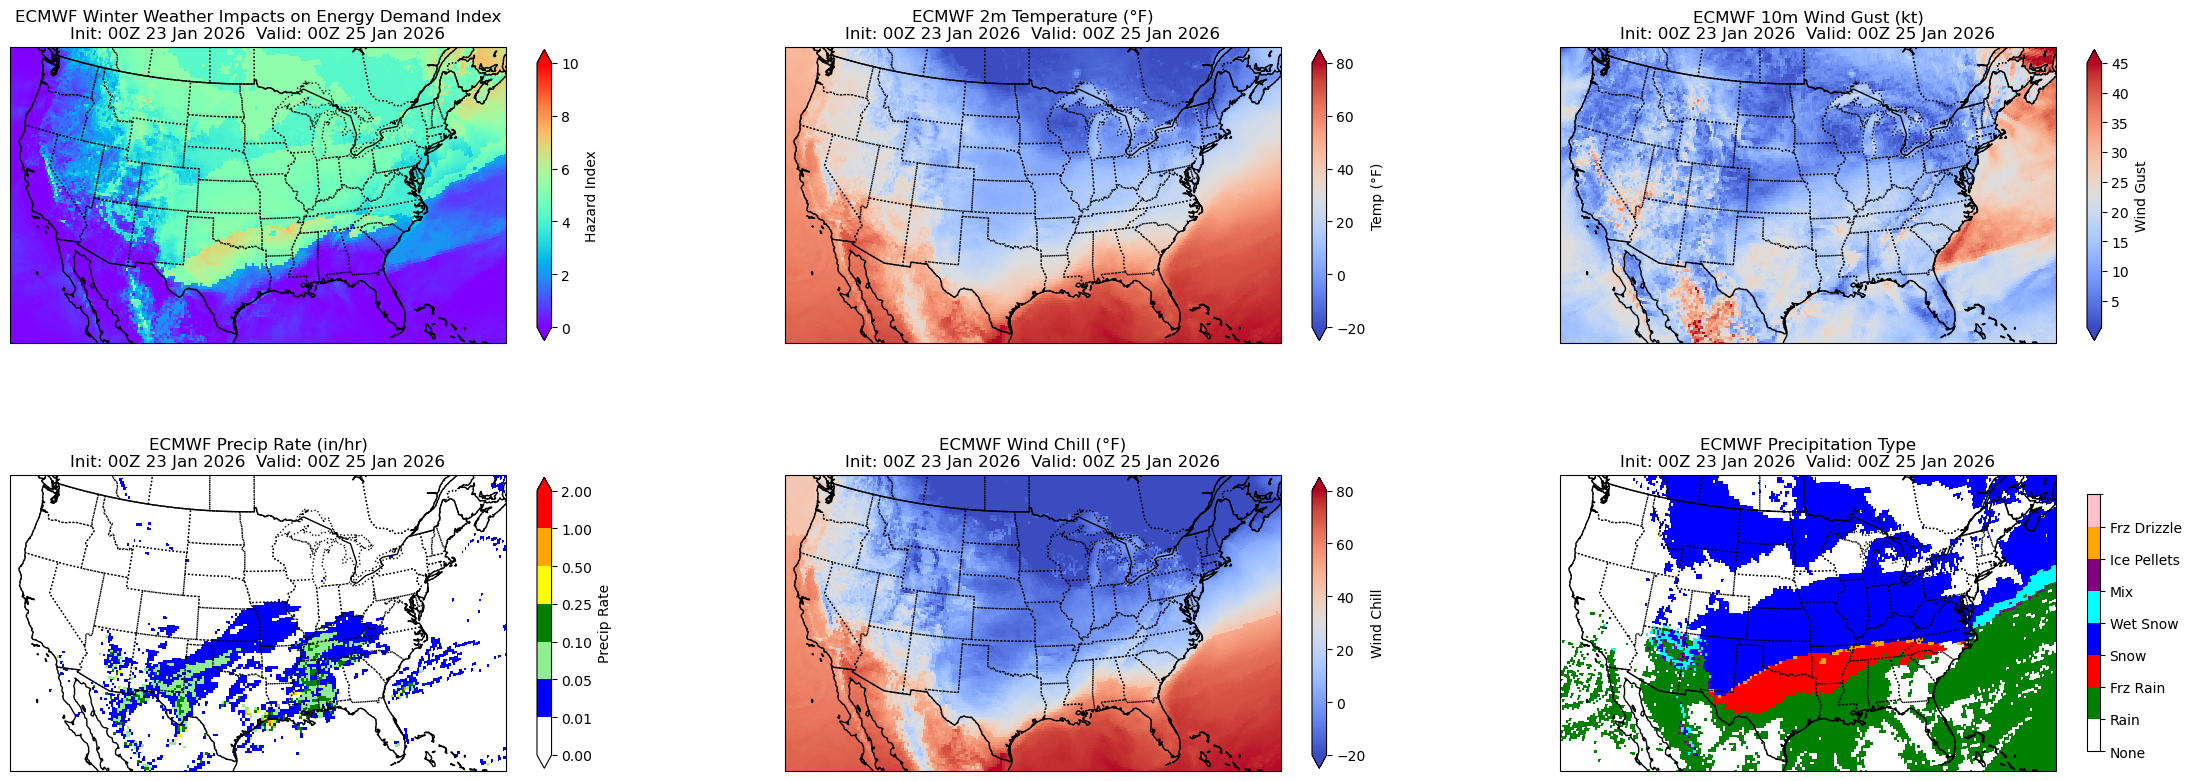

In [130]:
time_steps = [1, 3, 5, 8, 11, 14]

fig = plot_winter_threat(ds_test, 8, lon, lat)
plt.show()

## Timestep 11 (2026-01-25 18UTC) (MP)

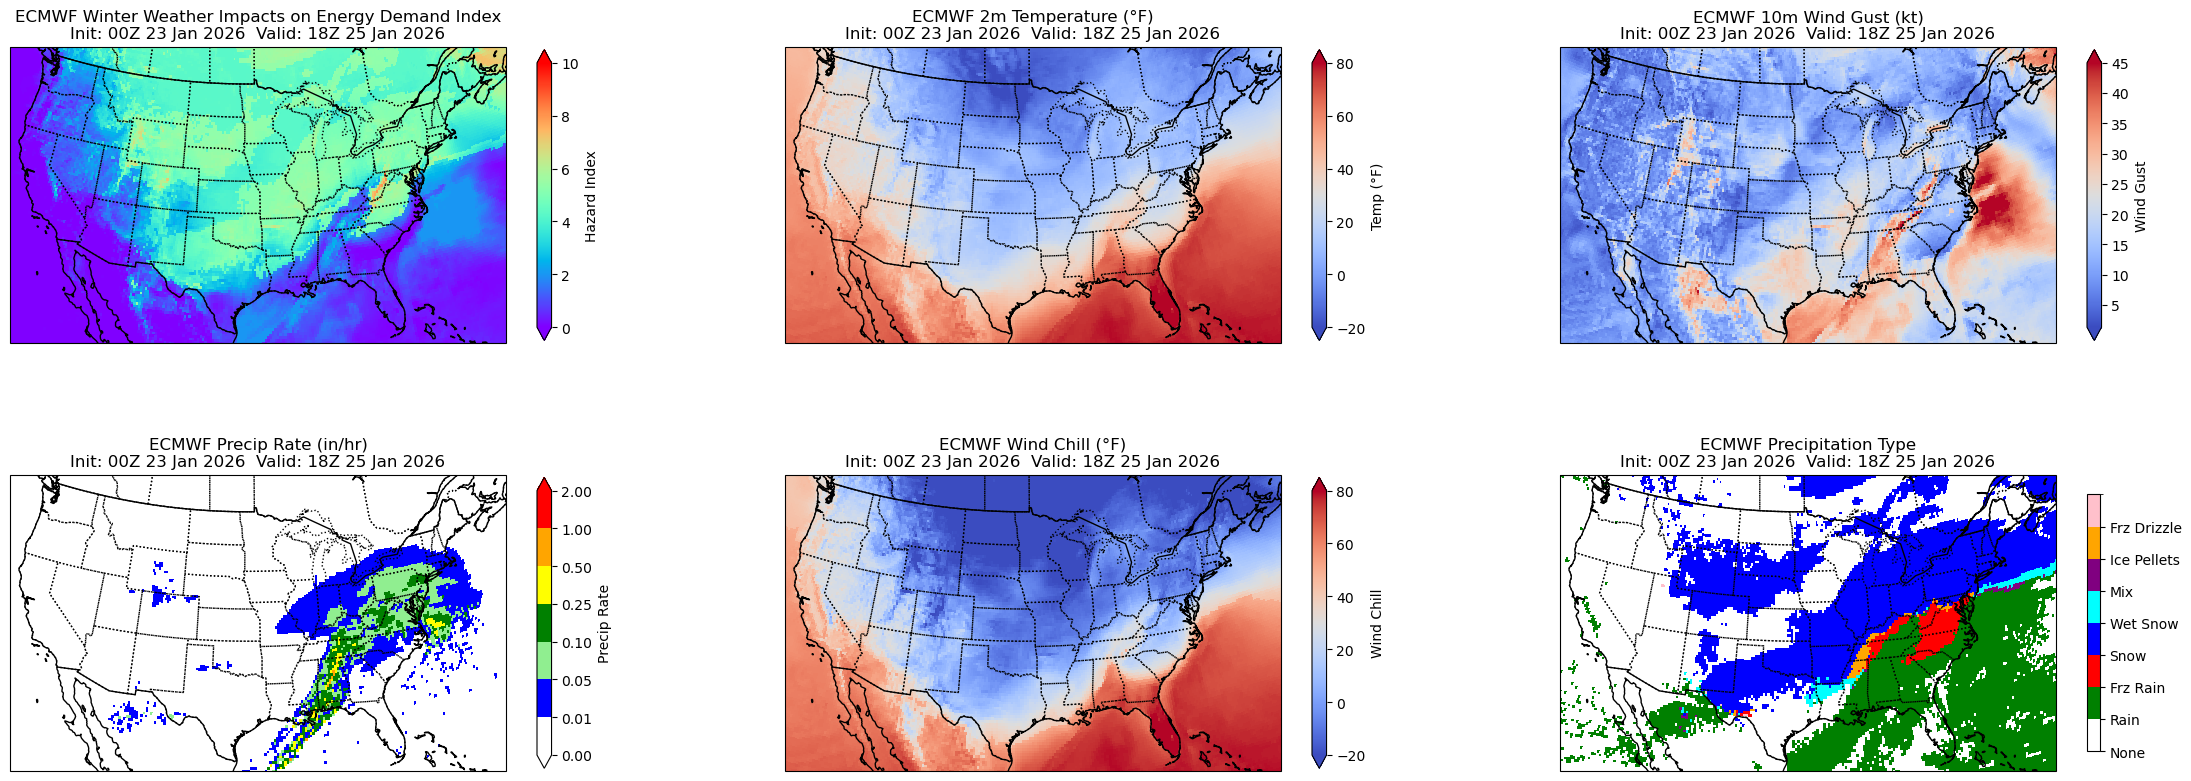

In [131]:
time_steps = [1, 3, 5, 8, 11, 14]

fig = plot_winter_threat(ds_test, 11, lon, lat)
plt.show()

## Timestep 14 (2026-01-26 12UTC) (PD)

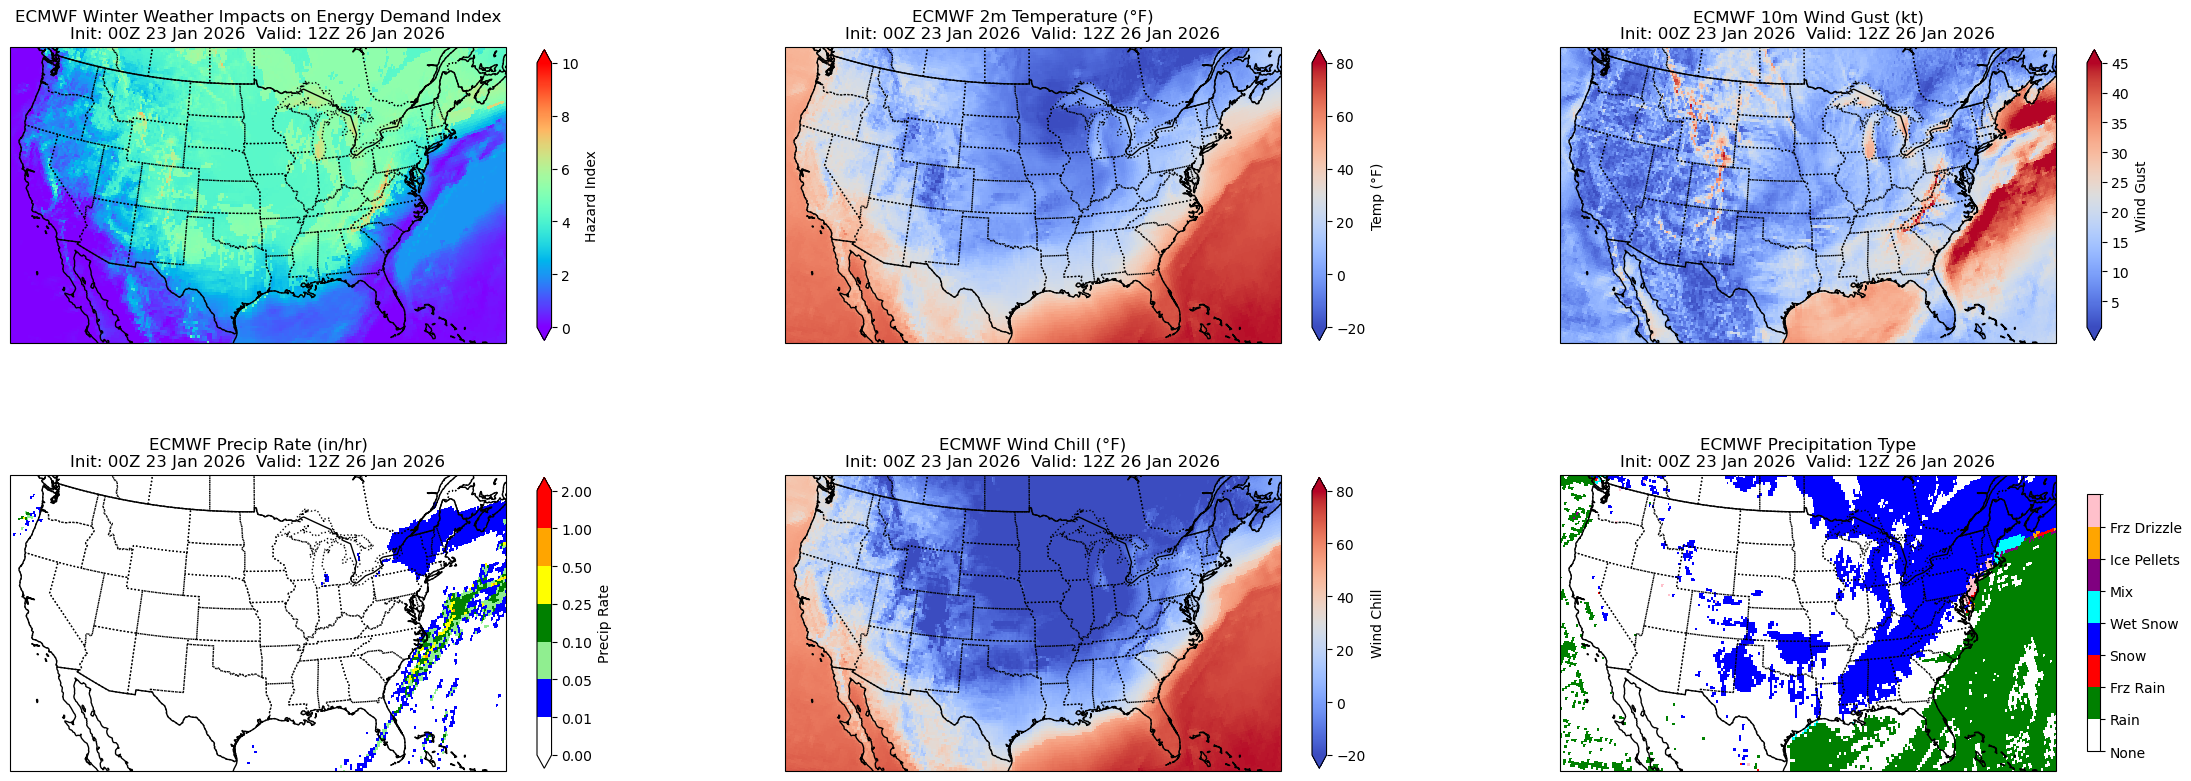

In [132]:
time_steps = [1, 3, 5, 8, 11, 14]

fig = plot_winter_threat(ds_test, 14, lon, lat)
plt.show()

# Additional Events (one high end one low end)

In [133]:
from herbie import Herbie, FastHerbie

## Low End Case (MP)
- Jan 17/18 2026, light snow across northeast region

In [196]:
# using code from milestone 1 to save new runs
run = pd.Timestamp("2026-01-17-00")
H = FastHerbie([run], model="ifs", product="oper", fxx=np.arange(0,54,6).tolist(), save_dir='./data/', overwrite=True)

In [197]:
ss1 = r":(2t):"
ss2 = r":(gh|t|u|v|sd|10fg|sp|ws|tp|ptype|tprate):" 

In [198]:
filepath1 = H.download(ss1)
filepath2 = H.download(ss2)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

In [199]:
ds1 = xr.open_mfdataset(filepath1, combine='nested', concat_dim='valid_time')
ds2 = xr.open_mfdataset(filepath2, combine='nested', concat_dim='valid_time', coords = 'minimal', compat = 'override')
ds = xr.merge([ds1, ds2], compat = 'override', combine_attrs = 'override')

Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260117/subset_bcef4d3c__20260117000000-0h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260117/subset_bc1c22e6__20260117000000-48h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260117/subset_bc0e15aa__20260117000000-36h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260117/subset_bce72664__20260117000000-42h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260117/subset_bc127441__20260117000000-12h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260117/subset_bcb2d9c9__20260117000000-6h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp2

In [200]:
ds = ds.sortby('valid_time')

In [201]:
ds = ds.sel(latitude=slice(60,20), longitude=slice(-130,-60))

In [202]:
fname = f'ecmwf_low_end.nc'
ds.to_netcdf(fname)

## Only need to run this

In [134]:
ds_low = xr.open_dataset("ecmwf_low_end.nc").load()
ds_low

sh: 1: getfattr: not found


<xarray.Dataset> Size: 96MB
Dimensions:            (valid_time: 9, latitude: 161, longitude: 281,
                        isobaricInhPa: 13)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 72B 2026-01-17 ... 2026-01-19
  * latitude           (latitude) float64 1kB 60.0 59.75 59.5 ... 20.25 20.0
  * longitude          (longitude) float64 2kB -130.0 -129.8 ... -60.25 -60.0
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-01-17
    step               (valid_time) timedelta64[ns] 72B 0 days 00:00:00 ... 2...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Data variables:
    t2m                (valid_time, latitude, longitude) float32 2MB 274.4 .....
    fg10               (valid_time, latitude, longitude) float32 2MB 0.0 ... ...
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    tp                 (valid_time, latitude, longitude) float32 2MB 0.0 ... ...
    sd                 (valid_time, latitude, longitude) float32 2MB 0.1384 ....
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    ptype              (valid_time, latitude, longitude) float32 2MB 0.0 ... 0.0
    tprate             (valid_time, latitude, longitude) float32 2MB 0.0 ... 0.0
    sp                 (valid_time, latitude, longitude) float32 2MB 8.889e+0...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-15T15:50 GRIB to CDM+CF via cfgrib-0.9.1...

In [204]:
ds_low.valid_time

<xarray.DataArray 'valid_time' (valid_time: 9)> Size: 72B
array(['2026-01-17T00:00:00.000000000', '2026-01-17T06:00:00.000000000',
       '2026-01-17T12:00:00.000000000', '2026-01-17T18:00:00.000000000',
       '2026-01-18T00:00:00.000000000', '2026-01-18T06:00:00.000000000',
       '2026-01-18T12:00:00.000000000', '2026-01-18T18:00:00.000000000',
       '2026-01-19T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 72B 2026-01-17 ... 2026-01-19
    time               datetime64[ns] 8B 2026-01-17
    step               (valid_time) timedelta64[ns] 72B 0 days 00:00:00 ... 2...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Attributes:
    standard_name:  time
    long_name:      time

In [135]:
def get_time_strings(ds, time_index):

    init_time = pd.to_datetime(ds.valid_time.values[0])
    valid_time = pd.to_datetime(ds.valid_time.values[time_index])

    init_str = init_time.strftime("%HZ %d %b %Y")
    valid_str = valid_time.strftime("%HZ %d %b %Y")

    return init_str, valid_str

In [136]:
get_time_strings(ds_low, 4)

('00Z 17 Jan 2026', '00Z 18 Jan 2026')

In [139]:
threat_index_new = compute_threat_index_full(ds_low, 4)

Text(0.5, 1.0, 'ECMWF Winter Weather Impacts on Energy Demand Index\nInit: 00Z 17 Jan 2026  Valid: 00Z 18 Jan 2026')

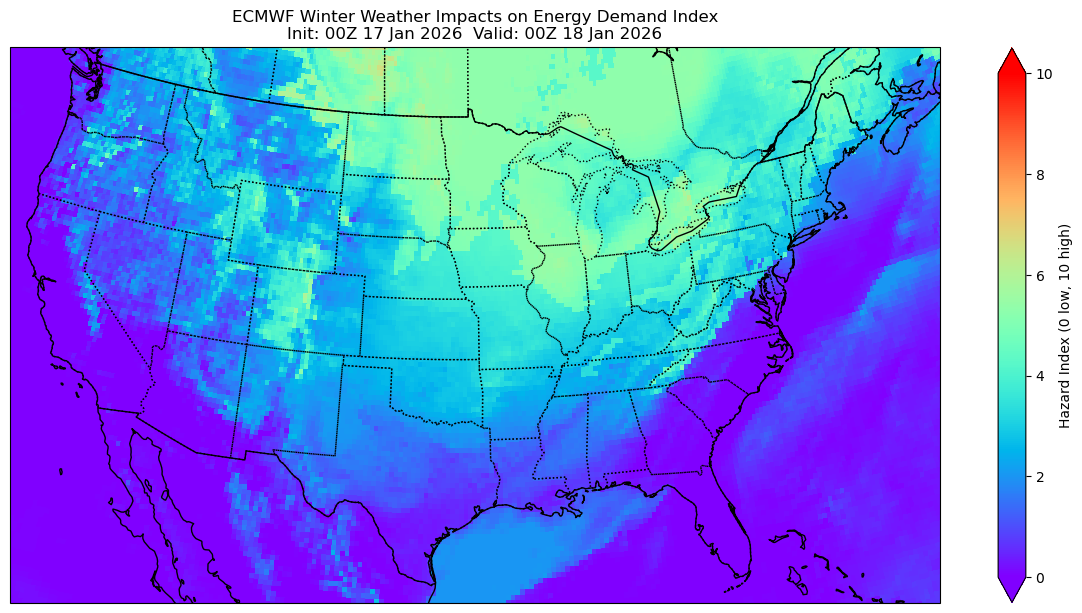

In [141]:
fig, ax = GeoAxes()

init_str, valid_str = get_time_strings(ds_low, 4)
mesh = ax.pcolormesh(lon, lat, threat_index_new, vmin=0, vmax=10, cmap = 'rainbow',  transform=ccrs.PlateCarree())
plt.colorbar(mesh, label = 'Hazard Index (0 low, 10 high)', extend = 'both', shrink=0.8)
ax.set_title(f"ECMWF Winter Weather Impacts on Energy Demand Index\nInit: {init_str}  Valid: {valid_str}")

## High End Case (PD)
- Winter storm Feb 22-23, 2026

In [257]:
# using code from milestone 1 to save new runs
run = pd.Timestamp("2026-02-22-00")
H = FastHerbie([run], model="ifs", product="oper", fxx=np.arange(0,54,6).tolist(), save_dir='./data/', overwrite=True)

In [258]:
ss1 = r":(2t):"
ss2 = r":(gh|t|u|v|sd|10fg|sp|ws|tp|ptype|tprate):" 

In [259]:
filepath1 = H.download(ss1)
filepath2 = H.download(ss2)

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

In [260]:
ds1 = xr.open_mfdataset(filepath1, combine='nested', concat_dim='valid_time')
ds2 = xr.open_mfdataset(filepath2, combine='nested', concat_dim='valid_time', coords = 'minimal', compat = 'override')
ds = xr.merge([ds1, ds2], compat = 'override', combine_attrs = 'override')

Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260222/subset_9212a8c6__20260222000000-12h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260222/subset_92ef4d8c__20260222000000-0h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260222/subset_921c2f9a__20260222000000-48h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260222/subset_92e748ac__20260222000000-42h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260222/subset_92b22664__20260222000000-6h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp26/473_sp26_group6/data/ifs/20260222/subset_920ec4ed__20260222000000-36h-oper-fc.grib2.5b7b6.idx' older than GRIB file
Ignoring index file '/courses/meteo473/sp2

In [261]:
ds = ds.sortby('valid_time')

In [262]:
ds = ds.sel(latitude=slice(60,20), longitude=slice(-130,-60))

In [263]:
fname = f'ecmwf_high_end_feb.nc'
ds.to_netcdf(fname)

## Only need this cell

In [142]:
ds_high = xr.open_dataset("ecmwf_high_end_feb.nc").load()
ds_high

sh: 1: getfattr: not found


<xarray.Dataset> Size: 96MB
Dimensions:            (valid_time: 9, latitude: 161, longitude: 281,
                        isobaricInhPa: 13)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 72B 2026-02-22 ... 2026-02-24
  * latitude           (latitude) float64 1kB 60.0 59.75 59.5 ... 20.25 20.0
  * longitude          (longitude) float64 2kB -130.0 -129.8 ... -60.25 -60.0
  * isobaricInhPa      (isobaricInhPa) float64 104B 1e+03 925.0 ... 100.0 50.0
    time               datetime64[ns] 8B 2026-02-22
    step               (valid_time) timedelta64[ns] 72B 0 days 00:00:00 ... 2...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Data variables:
    t2m                (valid_time, latitude, longitude) float32 2MB 249.9 .....
    fg10               (valid_time, latitude, longitude) float32 2MB 0.0 ... ...
    gh                 (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    v                  (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    t                  (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    u                  (valid_time, isobaricInhPa, latitude, longitude) float32 21MB ...
    sd                 (valid_time, latitude, longitude) float32 2MB 0.1794 ....
    tp                 (valid_time, latitude, longitude) float32 2MB 0.0 ... ...
    ptype              (valid_time, latitude, longitude) float32 2MB 5.0 ... 0.0
    tprate             (valid_time, latitude, longitude) float32 2MB 5.245e-0...
    sp                 (valid_time, latitude, longitude) float32 2MB 8.979e+0...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-15T16:24 GRIB to CDM+CF via cfgrib-0.9.1...

In [265]:
ds_high.valid_time

<xarray.DataArray 'valid_time' (valid_time: 9)> Size: 72B
array(['2026-02-22T00:00:00.000000000', '2026-02-22T06:00:00.000000000',
       '2026-02-22T12:00:00.000000000', '2026-02-22T18:00:00.000000000',
       '2026-02-23T00:00:00.000000000', '2026-02-23T06:00:00.000000000',
       '2026-02-23T12:00:00.000000000', '2026-02-23T18:00:00.000000000',
       '2026-02-24T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 72B 2026-02-22 ... 2026-02-24
    time               datetime64[ns] 8B 2026-02-22
    step               (valid_time) timedelta64[ns] 72B 0 days 00:00:00 ... 2...
    heightAboveGround  float64 8B 2.0
    surface            float64 8B 0.0
Attributes:
    standard_name:  time
    long_name:      time

In [143]:
def get_time_strings(ds, time_index):

    init_time = pd.to_datetime(ds.valid_time.values[0])
    valid_time = pd.to_datetime(ds.valid_time.values[time_index])

    init_str = init_time.strftime("%HZ %d %b %Y")
    valid_str = valid_time.strftime("%HZ %d %b %Y")

    return init_str, valid_str

In [144]:
get_time_strings(ds_high, 6)

('00Z 22 Feb 2026', '12Z 23 Feb 2026')

In [145]:
threat_index_new = compute_threat_index_full(ds_high, 6)

Text(0.5, 1.0, 'ECMWF Winter Weather Impacts on Energy Demand Index\nInit: 00Z 22 Feb 2026  Valid: 12Z 23 Feb 2026')

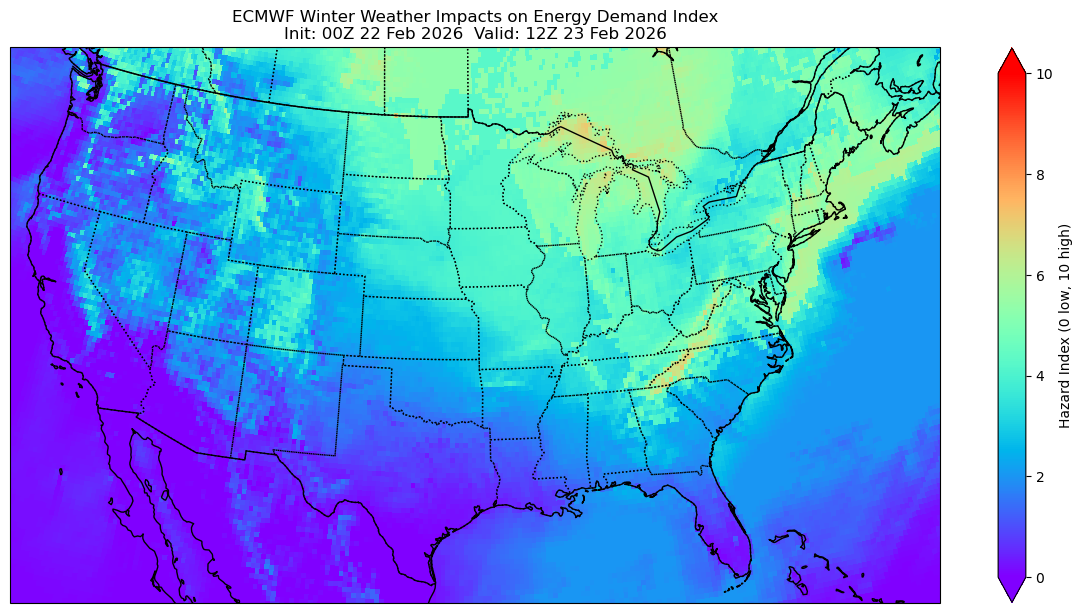

In [146]:
fig, ax = GeoAxes()

init_str, valid_str = get_time_strings(ds_high, 6)
mesh = ax.pcolormesh(lon, lat, threat_index_new, vmin=0, vmax=10, cmap = 'rainbow',  transform=ccrs.PlateCarree())
plt.colorbar(mesh, label = 'Hazard Index (0 low, 10 high)', extend = 'both', shrink=0.8)
ax.set_title(f"ECMWF Winter Weather Impacts on Energy Demand Index\nInit: {init_str}  Valid: {valid_str}")

## Performance (MP and PD)
- Maximum and minimum values make sense on both plots with it being consistent with our first data download
- One problem is these values not reaching the theoretical max of 10, but the max value is only for worst possible scenarios that only happen a few times every century with extremely impactful winter storms and extremely frigid wind chills that make very far south into the U.S, since people in the southern U.S. cannot tolerate extreme cold as well as those in the northern U.S.
- There doesn't seem to be false alarms. Most slightly increased areas are due to high wind gusts and very low temperatures which can still cause problems either way for energy demand
- For example, in the low end case there are very high values in the Minnesota and Iowa which was due to extreme cold. For our focus on the low end, we were looking at the northeast, and these values were not as significant than the high end case
- Comparing the northeast in both scenarios, the high end case has significantly lager values (which was what we were expecting)
- In the high end case you can see the strong winds associated with the storm off the coast of Virginia all the way up to Maine (pretty cool)
- We didn't make any changes to the index as we thought that these values were significant enough in our index
- We also had trouble with the high end case for a speficic event; we tried to use more significant snow storms but the data was either out of range (too far back from when the ECMWF started saving data) or certain variables (such as 10m wind gust) was not available, so we had to settle for the Noreaster in late February of this year

# Automate Plot Generation (MP)
*Note - The final timestep plot has a different look to the others due to wind gust data not being available for this timestep

In [306]:
n_times = len(ds_test.valid_time)
n_times

17

In [317]:
# creating loop for generation
for t in range(n_times):

    # compute hazard index for this timestep
    hazard_index = compute_threat_index_full(ds_test, t)

    # time strings
    init_str, valid_str = get_time_strings(ds_test, t)
    # figure
    fig, ax = GeoAxes() 
    mesh = ax.pcolormesh(
        lon, lat, hazard_index, vmin=0, vmax=10, cmap="rainbow", transform=ccrs.PlateCarree())
    plt.colorbar(mesh, ax=ax, shrink=0.8, label="Hazard Index (0–10)")
    ax.set_title(f"ECMWF Winter Weather Threat Hazard Impact on Energy Demand\n"f"Init: {init_str}  Valid: {valid_str}")
    # format filename using forecast hour
    lead_hours = t * 6   
    filename = f"winter_threat_{lead_hours:03d}.png"
    plt.savefig(filename)
    plt.close(fig)

# Creating Python Script (MP)
- created the winter threat index as a .py script that is attached at the bottom of our group 6 files
- then transferred this to the terminal to save each image to website/images area

# Bonus: Cron Job
- Tried to develop cron job
- Created another python script to download the latest ecmwf data
- Was not entirely sure how this worked. I think I installed the cron job correctly, I am just not sure if it is updating.
- The winter_threat_index.py has all of the code needed that generated the images into the website folder and works well for part 6
- Used AI for assistance in understanding how the cron window worked and the filepath arguments